# 集成学习部分的可视化

## 导入数据集

In [16]:
from dataloader import load_data
X_train, X_test, y_train, y_test = load_data()
print(f"Shape of training set: {X_train.shape}, {y_train.shape}")
print(f"Shape of testing set: {X_test.shape}, {y_test.shape}")

# Load name of the feature
import pandas as pd
df = pd.read_csv("../data/breast_cancer.csv")
feature_names = df.columns.to_list()
del df # to avoid test data leaks

import numpy as np
df_train = pd.DataFrame(
    data = np.hstack([X_train, y_train[:, np.newaxis]]),
    columns = feature_names,
)
df_train.head()

Shape of training set: (455, 30), (455,)
Shape of testing set: (114, 30), (114,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target_class
0,-1.072001,-0.658425,-1.088080,-0.939274,-0.135940,-1.008718,-0.968359,-1.102032,0.281062,-0.113231,...,-0.623497,-1.070773,-0.876534,-0.169982,-1.038836,-1.078995,-1.350527,-0.352658,-0.541380,1.0
1,1.748743,0.066502,1.751157,1.745559,1.274468,0.842288,1.519852,1.994664,-0.293045,-0.320180,...,-0.092833,1.187467,1.104386,1.517001,0.249655,1.178594,1.549916,0.191078,-0.173739,0.0
2,-0.974734,-0.931124,-0.997709,-0.867589,-0.613515,-1.138154,-1.092292,-1.243358,0.434395,-0.429247,...,-1.036772,-1.008044,-0.834168,-1.097823,-1.167260,-1.282241,-1.707442,-0.307734,-1.213033,1.0
3,-0.145103,-1.215186,-0.123013,-0.253192,0.664482,0.286762,-0.129729,-0.098605,0.555635,0.029395,...,-1.369643,-0.166633,-0.330292,0.234006,0.096874,-0.087521,-0.344838,0.242198,-0.118266,1.0
4,-0.771617,-0.081211,-0.803700,-0.732927,-0.672282,-1.006099,-0.798502,-0.684484,0.737495,-0.457213,...,0.079230,-0.824381,-0.741830,-0.911367,-0.984612,-0.933190,-0.777604,0.555118,-0.761639,1.0


In [17]:
print((df_train['target_class'] == 1).sum())
print((df_train['target_class'] == 0).sum())

285
170


## 模型训练的可视化

In [18]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_decision_boundary_2D(model, X, y, method_name):
    """
    将高维数据 PCA 到 2D，再可视化 SVM 决策边界。
    假设 X 已经过标准化处理。
    """
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    # 创建网格用于绘图
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # 网格点逆 PCA 回高维
    grid_2d = np.c_[xx.ravel(), yy.ravel()]
    grid_hd = pca.inverse_transform(grid_2d)

    Z = model.predict_proba(grid_hd)
    Z = Z.reshape(xx.shape)

    # 绘制结果 (不创建新图，直接画在当前子图)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    # 绘制决策边界
    plt.contour(xx, yy, Z, levels=[0.5], colors='k', linestyles='--')
    # 绘制数据点
    plt.scatter(
        X_2d[:, 0], X_2d[:, 1],
        c=y, edgecolors='k', cmap="coolwarm"
    )
    
    plt.title(f"{method_name}")
    # plt.xlabel("PCA Component 1")
    # plt.ylabel("PCA Component 2")

In [19]:
adaboost_path = "../results/latest_adaboost/adaboost.pkl"
# gbdt_path = "../results/20251230-212300_gbdt/gbdt.pkl"
gbdt_path = "../results/latest_gbdt/gbdt.pkl"

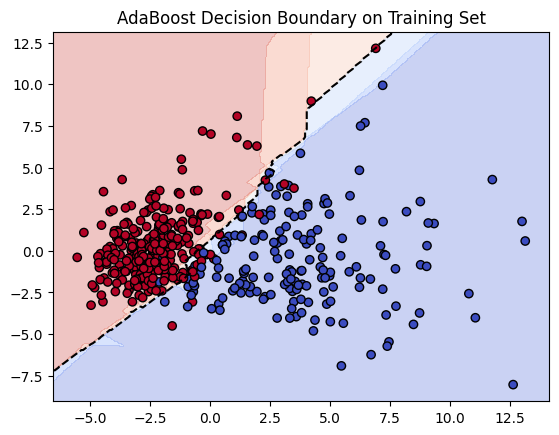

In [20]:
# Use plot_decision_boundary_2D in your code to visualize decision boundaries.
import joblib
adaboost_model = joblib.load(adaboost_path)
plot_decision_boundary_2D(
    adaboost_model, X_train, y_train,
    method_name="AdaBoost Decision Boundary on Training Set"
)

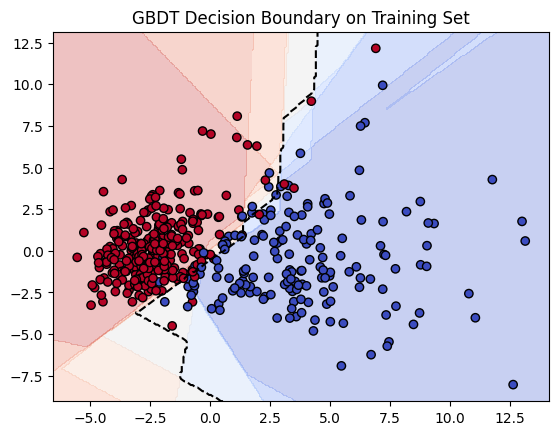

In [21]:
# gbdt_path = "../results/20251230-194250_gbdt/gbdt.pkl"
# gbdt_path = "../results/20251230-212217_gbdt/gbdt.pkl"
gbdt_model = joblib.load(gbdt_path)
plot_decision_boundary_2D(
    gbdt_model, X_train, y_train,
    method_name="GBDT Decision Boundary on Training Set"
)

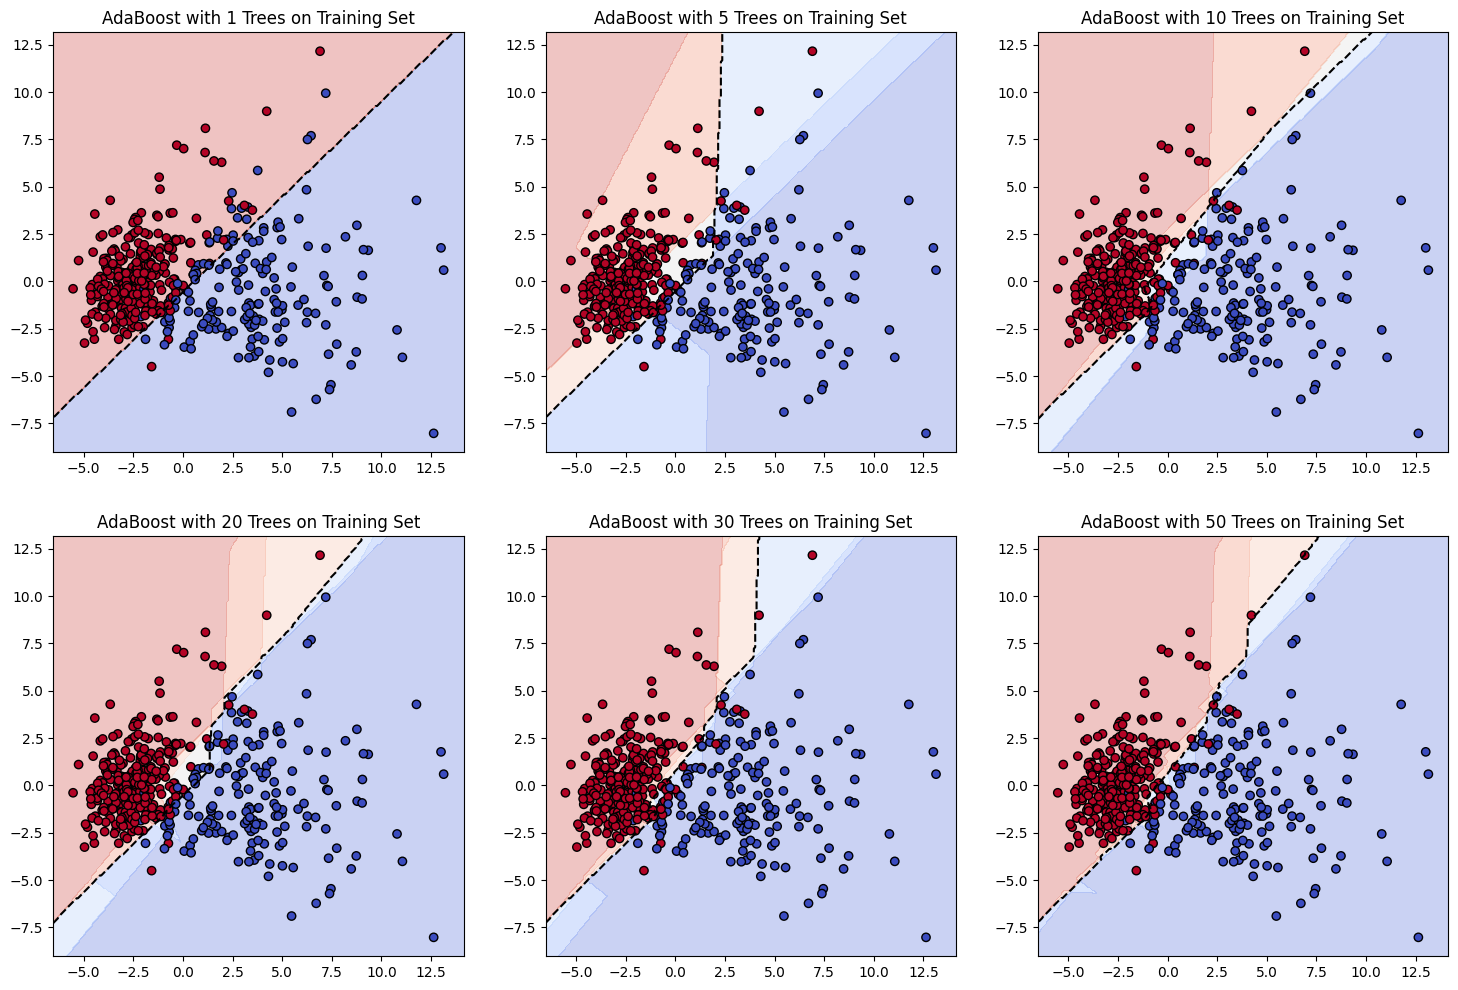

In [22]:
from submission import truncate_adaboost_model

num_models = [1, 5, 10, 20, 30, 50]
plt.subplots(2, 3, figsize=(18, 12))

adaboost_model = joblib.load(adaboost_path)

for i, n in enumerate(num_models):
    plt.subplot(2, 3, i+1)
    adaboost_truncated = truncate_adaboost_model(adaboost_model, n)
    plot_decision_boundary_2D(
        adaboost_truncated, X_train, y_train,
        method_name=f"AdaBoost with {n} Trees on Training Set"
    )

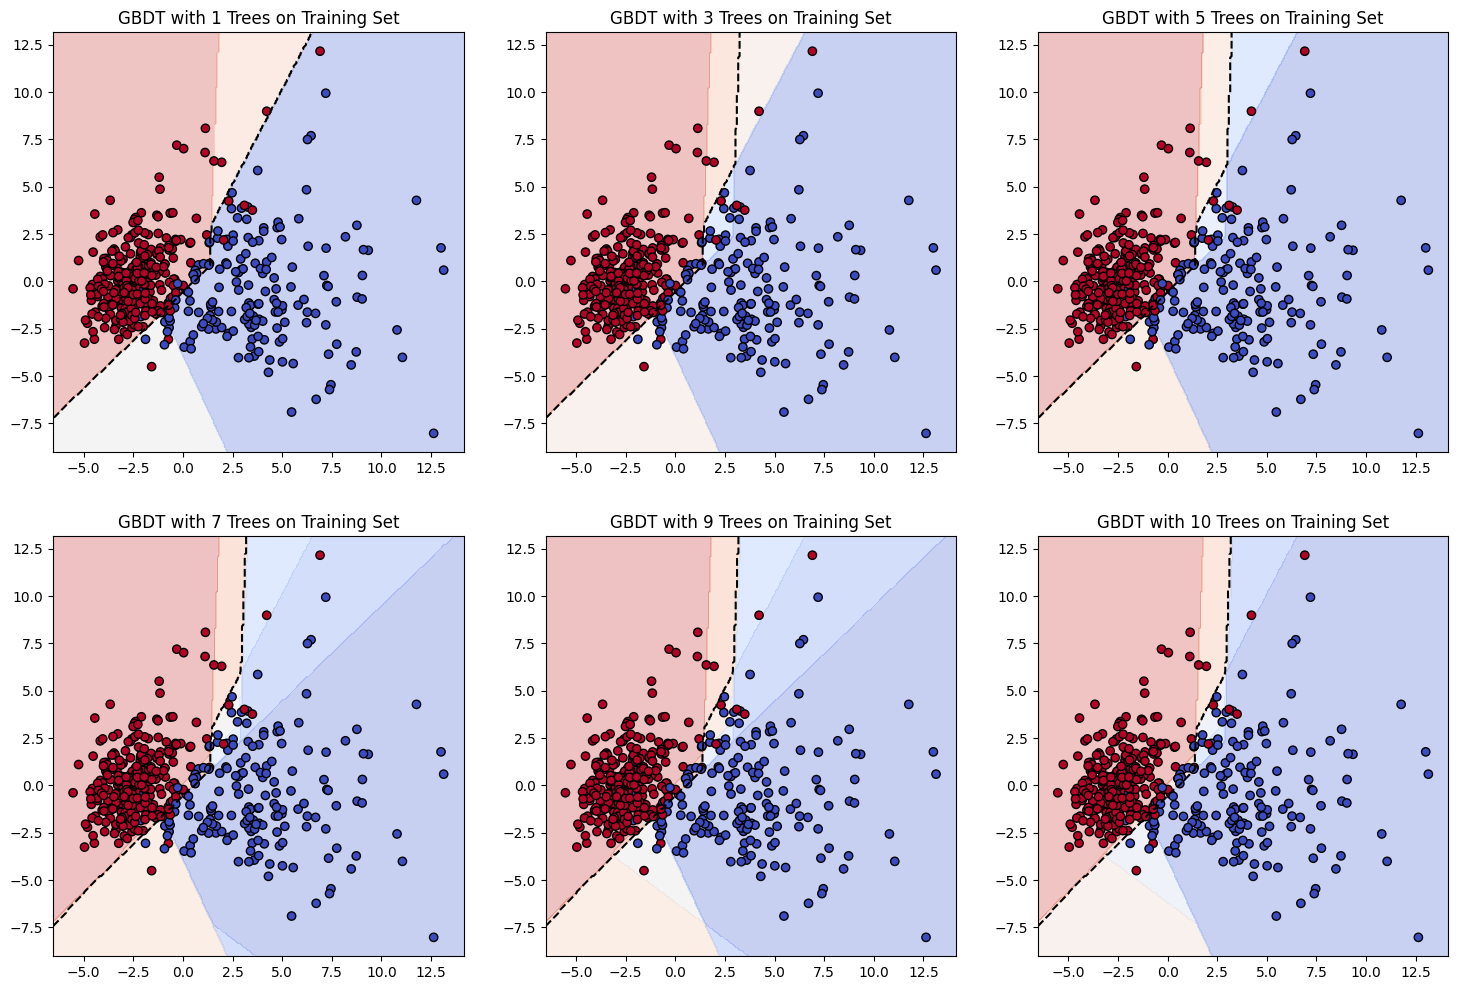

In [23]:
from submission import truncate_gbdt_model

num_models = [1, 3, 5, 7, 9, 10]
plt.subplots(2, 3, figsize=(18, 12))

gbdt_model = joblib.load(gbdt_path)

for i, n in enumerate(num_models):
    plt.subplot(2, 3, i+1)
    gbdt_truncated = truncate_gbdt_model(gbdt_model, n)
    plot_decision_boundary_2D(
        gbdt_truncated, X_train, y_train,
        method_name=f"GBDT with {n} Trees on Training Set"
    )

## 模型训练的可视化

In [24]:
np.sign(np.array([0, 2, -3, 4, -5]))

array([ 0,  1, -1,  1, -1])